# DBGSOM vs. MiniSom vs. SuSi — Comparison

This notebook compares DBGSOM (`SomVQ`) with [justglowing/minisom](https://github.com/JustGlowing/minisom) and [felixriese/susi](https://github.com/felixriese/susi) on the scikit-learn Digits dataset.

## Algorithm Overview

| Property         | DBGSOM                                                              | MiniSom                         | SuSi                                         |
| ---------------- | ------------------------------------------------------------------- | ------------------------------- | -------------------------------------------- |
| Learning rule    | **Batch** (all samples per epoch)                                   | **Online** (sample-by-sample)   | Online or **Batch**                          |
| Grid topology    | Rectangular (grows dynamically)                                     | Rectangular / hexagonal (fixed) | Rectangular (fixed)                          |
| Growth criterion | Neuron added where accumulated error exceeds growing threshold (GT) | —                               | —                                            |
| Initialization   | 4 neurons (chosen from training samples)                            | Random or PCA                   | Random or PCA                                |
| API              | **sklearn-compatible** (`fit` / `transform` / `predict`)            | Custom API (`train` / `winner`) | **sklearn-compatible** (`fit` / `transform`) |
| Neighborhood     | Gaussian decay over epochs                                          | Gaussian decay over iterations  | Pseudo-Gaussian or Mexican Hat               |
| Distance metrics | Euclidean, Cosine                                                   | Euclidean                       | Euclidean, Manhattan, Mahalanobis, Tanimoto  |

> **Same topology, different sizing:** All three SOMs use a rectangular grid. The key difference is that DBGSOM determines the grid size dynamically: a new neuron is inserted adjacent to all neurons whose error exceeds the growing threshold GT. MiniSom and SuSi require grid dimensions to be fixed before training.

**Fair comparison:** Because DBGSOM grows dynamically, we first train DBGSOM to determine its final neuron count `N`, then configure MiniSom and SuSi with a `ceil(sqrt(N)) × floor(sqrt(N))` grid — giving all models an approximately equal neuron budget.


## Imports


In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

from dbgsom.SomVQ import SomVQ

## Dataset

We use the scikit-learn **Digits** dataset: 1 797 samples, 64 features (8×8 pixel images of handwritten digits 0–9).


In [2]:
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
print(
    f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes"
)

Dataset: 1797 samples, 64 features, 10 classes


## Step 1 — Train DBGSOM

DBGSOM starts with 4 neurons and grows until `max_neurons` is reached or convergence is detected.


In [3]:
som_db = SomVQ(
    n_iter=500,
    spreading_factor=0.7,
    max_neurons=100,
    # learning_rate=0.01,
    decay_function="linear",
    sigma_end=1,
    verbose=True,
    random_state=42,
)

t0 = time.perf_counter()
som_db.fit(X)
t_db = time.perf_counter() - t0

n_neurons_db = len(som_db.neurons_)
print(f"DBGSOM: {n_neurons_db} neurons after {t_db:.2f}s")

 51%|█████▏    | 257/500 [00:01<00:01, 212.83 epochs/s]

DBGSOM: 45 neurons after 1.23s


## Step 2 — Train MiniSom

MiniSom uses a fixed rectangular grid. We choose `side = ceil(sqrt(N))` so the total neuron count is close to DBGSOM's final count.

MiniSom's `train_batch` uses the same batch update principle as DBGSOM (weights updated after all samples), making it the most comparable training mode.


In [4]:
side = math.ceil(math.sqrt(n_neurons_db))
side2 = math.floor(math.sqrt(n_neurons_db))
n_neurons_ms = side * side2

som_ms = MiniSom(
    x=side,
    y=side2,
    input_len=X.shape[1],
    sigma=0.2 * np.sqrt(side**2),
    learning_rate=0.5,
    random_seed=42,
)
som_ms.pca_weights_init(X)

# train_batch: batch update — closest to DBGSOM's learning rule
# num_iteration = epochs × n_samples for comparable training effort
t0 = time.perf_counter()
som_ms.train_batch(X, num_iteration=300 * len(X))
t_ms = time.perf_counter() - t0

print(f"MiniSom:  {n_neurons_ms} neurons ({side}×{side2} grid) after {t_ms:.2f}s")

MiniSom:  42 neurons (7×6 grid) after 22.31s


## Step 3 — Train SuSi

SuSi (`SOMClustering`) is an sklearn-compatible SOM library supporting online and batch training with multiple distance metrics. We use the same grid dimensions as MiniSom.

> **Note on topographic error:** SuSi does not provide a built-in topographic error. It is computed here using the same Kohonen definition as MiniSom: fraction of samples whose 1st and 2nd BMU are not adjacent in the grid.


In [5]:
from susi import SOMClustering

susi_rows, susi_cols = side, side2


def rectangular_topographic_error(weights_3d, X):
    n_rows, n_cols, _ = weights_3d.shape
    weights_flat = weights_3d.reshape(-1, X.shape[1])
    errors = 0
    for x in X:
        dists = np.linalg.norm(weights_flat - x, axis=1)
        idx1, idx2 = np.argsort(dists)[:2]
        r1, c1 = divmod(idx1, n_cols)
        r2, c2 = divmod(idx2, n_cols)
        if abs(r1 - r2) > 1 or abs(c1 - c2) > 1:
            errors += 1
    return errors / len(X)


t0 = time.perf_counter()
susi_som = SOMClustering(
    n_rows=susi_rows,
    n_columns=susi_cols,
    n_iter_unsupervised=1000,
    train_mode_unsupervised="online",
    random_state=42,
)
susi_som.fit(X)
t_susi = time.perf_counter() - t0

n_neurons_susi = susi_rows * susi_cols
print(
    f"SuSi:     {n_neurons_susi} neurons ({susi_rows}×{susi_cols} grid) after {t_susi:.2f}s"
)

SuSi:     42 neurons (7×6 grid) after 0.14s


## Step 4 — Metrics Comparison

> **Note on topographic error:** The three libraries measure topographic error differently:
>
> - **MiniSom** uses the standard Kohonen definition: fraction of samples whose 1st and 2nd BMU are _not adjacent_ in the grid.
> - **DBGSOM** (`topographic_error_`) stores the same Kohonen-style metric during training. `topographic_function()` implements the stricter Villmann et al. (1997) measure based on graph distances.
> - **SuSi** does not provide a built-in topographic error — it is computed here using the same Kohonen definition as MiniSom.
>
> The values are comparable at a high level (lower = better topology preservation), but not numerically identical across libraries.


In [6]:
qe_db = som_db.calculate_quantization_error(X)
qe_ms = som_ms.quantization_error(X)
qe_susi = susi_som.get_quantization_error()

te_db = som_db.topographic_error_
te_ms = som_ms.topographic_error(X)
te_susi = rectangular_topographic_error(susi_som.unsuper_som_, X)

metrics = pd.DataFrame(
    {
        "Metric": [
            "Training time (s)",
            "Neuron count",
            "Quantization error",
            "Topographic error",
        ],
        "DBGSOM": [
            f"{t_db:.2f}",
            n_neurons_db,
            f"{qe_db:.4f}",
            f"{te_db:.4f}",
        ],
        "MiniSom": [
            f"{t_ms:.2f}",
            n_neurons_ms,
            f"{qe_ms:.4f}",
            f"{te_ms:.4f}",
        ],
        "SuSi": [
            f"{t_susi:.2f}",
            n_neurons_susi,
            f"{qe_susi:.4f}",
            f"{te_susi:.4f}",
        ],
    }
).set_index("Metric")

metrics

,DBGSOM,MiniSom,SuSi
Metric,,,
Training time (s),1.23,22.31,0.14
Neuron count,45,42,42
Quantization error,5.2987,5.0426,5.9291
Topographic error,0.0634,0.1536,0.0250


## Step 5 — Visualization

All three SOMs are projected into the same 2D PCA space (PCA fitted on the data `X`), so neuron positions are directly comparable. Color encodes the mean distance to neighboring neurons (normalized to [0, 1]) — equivalent to a U-Matrix, darker = larger inter-neuron distances = cluster boundary.


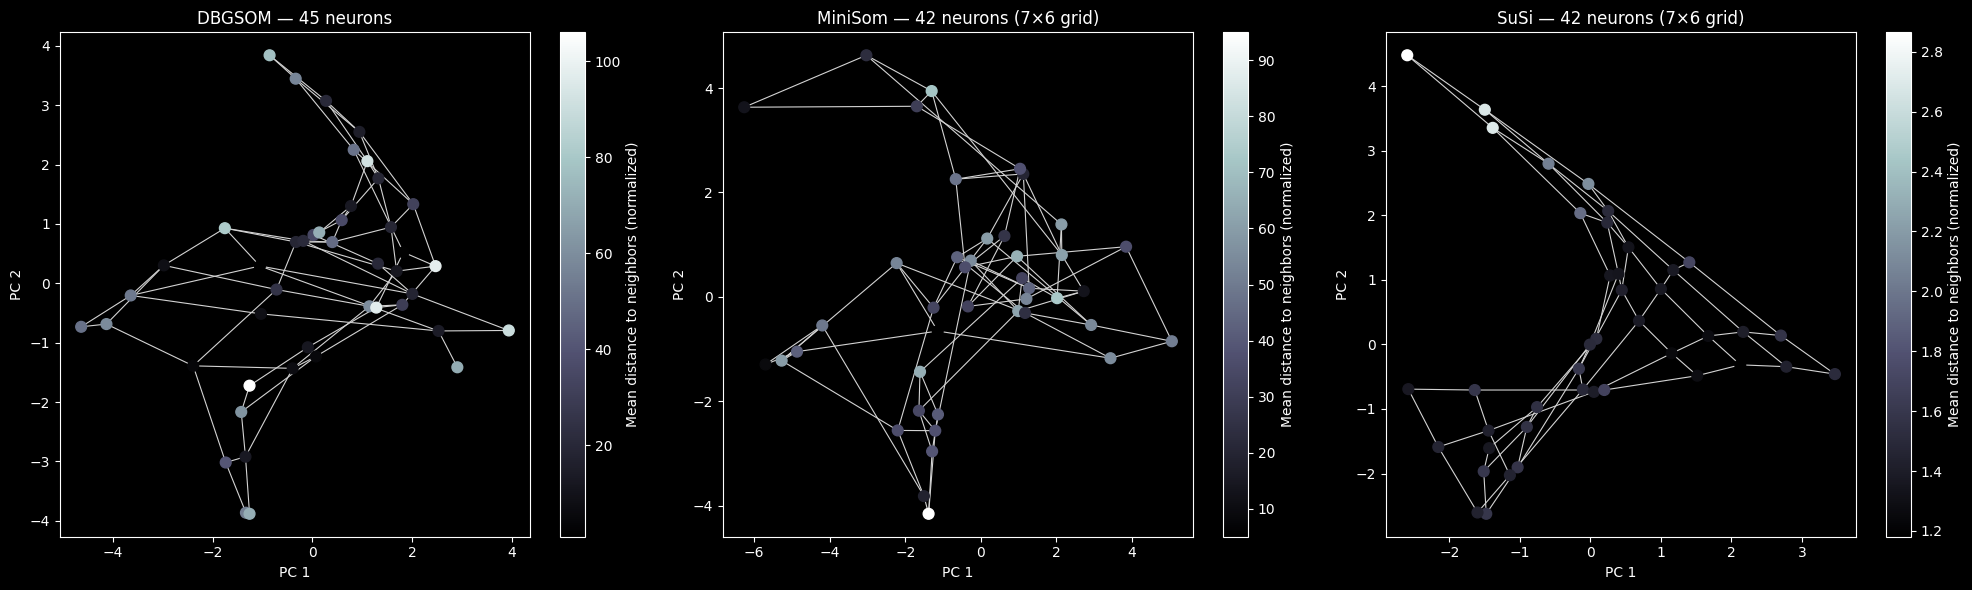

In [7]:
from sklearn.decomposition import PCA

# Fit PCA on the data so all SOMs share the same coordinate system
pca = PCA(n_components=2, random_state=42)
pca.fit(X)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- DBGSOM ---
weights_db_2d = pca.transform(som_db.weights_)
avg_dist = np.array(
    [som_db.som_.nodes[n].get("hit_count", 0.0) for n in som_db.neurons_]
)
avg_dist_norm = avg_dist

ax = axes[0]
ax.set_title(f"DBGSOM — {n_neurons_db} neurons", fontsize=12)

node_pos = dict(zip(som_db.neurons_, weights_db_2d))
for u, v in som_db.som_.edges():
    x0, y0 = node_pos[u]
    x1, y1 = node_pos[v]
    ax.plot([x0, x1], [y0, y1], color="lightgray", linewidth=0.8, zorder=1)

sc = ax.scatter(
    weights_db_2d[:, 0],
    weights_db_2d[:, 1],
    c=avg_dist_norm,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Mean distance to neighbors (normalized)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

# --- MiniSom ---
ms_weights = som_ms.get_weights()  # shape: (side, side2, n_features)
ms_weights_flat = ms_weights.reshape(-1, X.shape[1])
weights_ms_2d = pca.transform(ms_weights_flat)

umatrix = som_ms.activation_response(X)
umatrix_flat = umatrix.reshape(-1)

ax = axes[1]
ax.set_title(f"MiniSom — {n_neurons_ms} neurons ({side}×{side2} grid)", fontsize=12)

for i in range(side):
    for j in range(side2):
        idx = i * side2 + j
        if i + 1 < side:
            nb = (i + 1) * side2 + j
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < side2:
            nb = i * side2 + (j + 1)
            ax.plot(
                [weights_ms_2d[idx, 0], weights_ms_2d[nb, 0]],
                [weights_ms_2d[idx, 1], weights_ms_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

sc = ax.scatter(
    weights_ms_2d[:, 0],
    weights_ms_2d[:, 1],
    c=umatrix_flat,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Mean distance to neighbors (normalized)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

# --- SuSi ---
susi_weights_flat = susi_som.unsuper_som_.reshape(-1, X.shape[1])
weights_susi_2d = pca.transform(susi_weights_flat)

# get_u_matrix() returns extended U-matrix of shape (2*n_rows-1, 2*n_cols-1);
# [::2, ::2] selects only neuron positions (even indices), skipping inter-neuron distances
susi_umatrix = susi_som.get_u_matrix()[::2, ::2].reshape(-1)

ax = axes[2]
ax.set_title(
    f"SuSi — {n_neurons_susi} neurons ({susi_rows}×{susi_cols} grid)", fontsize=12
)

for i in range(susi_rows):
    for j in range(susi_cols):
        idx = i * susi_cols + j
        if i + 1 < susi_rows:
            nb = (i + 1) * susi_cols + j
            ax.plot(
                [weights_susi_2d[idx, 0], weights_susi_2d[nb, 0]],
                [weights_susi_2d[idx, 1], weights_susi_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )
        if j + 1 < susi_cols:
            nb = i * susi_cols + (j + 1)
            ax.plot(
                [weights_susi_2d[idx, 0], weights_susi_2d[nb, 0]],
                [weights_susi_2d[idx, 1], weights_susi_2d[nb, 1]],
                color="lightgray",
                linewidth=0.8,
                zorder=1,
            )

sc = ax.scatter(
    weights_susi_2d[:, 0],
    weights_susi_2d[:, 1],
    c=susi_umatrix,
    cmap="bone",
    s=60,
    zorder=2,
)
plt.colorbar(sc, ax=ax, label="Mean distance to neighbors (normalized)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

plt.tight_layout()
plt.show()

## Summary

| Aspect                    | DBGSOM                                     | MiniSom                                            | SuSi                                         |
| ------------------------- | ------------------------------------------ | -------------------------------------------------- | -------------------------------------------- |
| **Best for**              | Unknown optimal map size; automatic sizing | Quick experiments; well-understood grid size       | sklearn pipelines; multiple distance metrics |
| **Hyperparameter burden** | `spreading_factor`, `max_neurons`          | Grid dimensions `x`, `y`, `learning_rate`, `sigma` | Grid dimensions, `n_iter_unsupervised`       |
| **sklearn pipelines**     | Yes (`fit` / `transform` / `predict`)      | No (custom API)                                    | Yes (`fit` / `transform`)                    |
| **Growing overhead**      | Yes (error tracking + insertion per epoch) | No                                                 | No                                           |
| **Grid topology**         | Rectangular, size determined automatically | Rectangular / hexagonal, fixed upfront             | Rectangular, fixed upfront                   |
| **Distance metrics**      | Euclidean, Cosine                          | Euclidean                                          | Euclidean, Manhattan, Mahalanobis, Tanimoto  |
| **Maintained (2025)**     | ✓                                          | ✓ (bug fixes only)                                 | ✓                                            |

DBGSOM trades off a slightly higher training cost for the ability to adapt the map size automatically, which is beneficial when the ideal number of neurons is not known in advance. SuSi offers the broadest choice of distance metrics and full sklearn compatibility with a fixed grid.


---

## Scaling Test — Fashion-MNIST

To stress-test scaling behaviour we use a 10 000-sample subset of Fashion-MNIST (784 features, 10 classes) — roughly 5.6× more samples and 12× more features than Digits.

Training budgets are scaled proportionally:

- **DBGSOM**: same epoch count (`n_iter=300`), `max_neurons=100`
- **MiniSom**: `num_iteration = 50 × N` (reduced from 300× to keep runtime tractable)
- **SuSi**: `n_iter_unsupervised = 50 000` (~5× passes over all samples)

> **SuSi note:** In online mode each iteration draws _one_ random sample, independent of N. To expose the SOM to all data ~5 times we set `n_iter = 5 × N`. This is the key scaling difference from DBGSOM and MiniSom.


In [8]:
from sklearn.datasets import fetch_openml

fmnist = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_large = StandardScaler().fit_transform(fmnist.data[:10_000].astype(float))
y_large = fmnist.target[:10_000]

n_large = len(X_large)
print(
    f"Dataset: {X_large.shape[0]} samples, {X_large.shape[1]} features, {len(np.unique(y_large))} classes"
)

Dataset: 10000 samples, 784 features, 10 classes


In [9]:
som_db_l = SomVQ(
    n_iter=500,
    spreading_factor=0.99,
    max_neurons=200,
    neighborhood_function="cutgauss",
    verbose=True,
    convergence_threshold=1e-0,
    sigma_end=1.5,
    # sigma_fine=0.5,
    random_state=42,
)
t0 = time.perf_counter()
som_db_l.fit(X_large)
t_db_l = time.perf_counter() - t0
n_neurons_db_l = len(som_db_l.neurons_)
print(f"DBGSOM:  {n_neurons_db_l} neurons after {t_db_l:.2f}s")

side_l = math.ceil(math.sqrt(n_neurons_db_l))
side2_l = math.floor(math.sqrt(n_neurons_db_l))
n_neurons_ms_l = side_l * side2_l

som_ms_l = MiniSom(
    x=side_l,
    y=side2_l,
    input_len=X_large.shape[1],
    sigma=0.2 * np.sqrt(side_l**2),
    learning_rate=0.5,
    random_seed=42,
)
som_ms_l.pca_weights_init(X_large)
t0 = time.perf_counter()
som_ms_l.train_batch(X_large, num_iteration=1 * n_large)
t_ms_l = time.perf_counter() - t0
print(f"MiniSom: {n_neurons_ms_l} neurons ({side_l}×{side2_l}) after {t_ms_l:.2f}s")

susi_rows_l, susi_cols_l = side_l, side2_l
susi_som_l = SOMClustering(
    n_rows=susi_rows_l,
    n_columns=susi_cols_l,
    n_iter_unsupervised=1 * n_large,
    train_mode_unsupervised="online",
    random_state=42,
)
t0 = time.perf_counter()
susi_som_l.fit(X_large)
t_susi_l = time.perf_counter() - t0
n_neurons_susi_l = susi_rows_l * susi_cols_l
print(
    f"SuSi:    {n_neurons_susi_l} neurons ({susi_rows_l}×{susi_cols_l}) after {t_susi_l:.2f}s"
)

 50%|█████     | 251/500 [00:17<00:17, 14.34 epochs/s]


DBGSOM:  205 neurons after 18.01s
MiniSom: 210 neurons (15×14) after 15.59s
SuSi:    210 neurons (15×14) after 33.98s


In [10]:
qe_db_l = som_db_l.calculate_quantization_error(X_large)
qe_ms_l = som_ms_l.quantization_error(X_large)
qe_susi_l = susi_som_l.get_quantization_error()

te_db_l = som_db_l.topographic_error_
te_ms_l = som_ms_l.topographic_error(X_large)
te_susi_l = rectangular_topographic_error(susi_som_l.unsuper_som_, X_large)

pd.DataFrame(
    {
        "Metric": [
            "Training time (s)",
            "Neuron count",
            "Quantization error",
            "Topographic error",
        ],
        "DBGSOM": [
            f"{t_db_l:.2f}",
            n_neurons_db_l,
            f"{qe_db_l:.4f}",
            f"{te_db_l:.4f}",
        ],
        "MiniSom": [
            f"{t_ms_l:.2f}",
            n_neurons_ms_l,
            f"{qe_ms_l:.4f}",
            f"{te_ms_l:.4f}",
        ],
        "SuSi": [
            f"{t_susi_l:.2f}",
            n_neurons_susi_l,
            f"{qe_susi_l:.4f}",
            f"{te_susi_l:.4f}",
        ],
    }
).set_index("Metric")

,DBGSOM,MiniSom,SuSi
Metric,,,
Training time (s),18.01,15.59,33.98
Neuron count,205,210,210
Quantization error,16.4886,16.7344,17.0987
Topographic error,0.0886,0.0302,0.0141


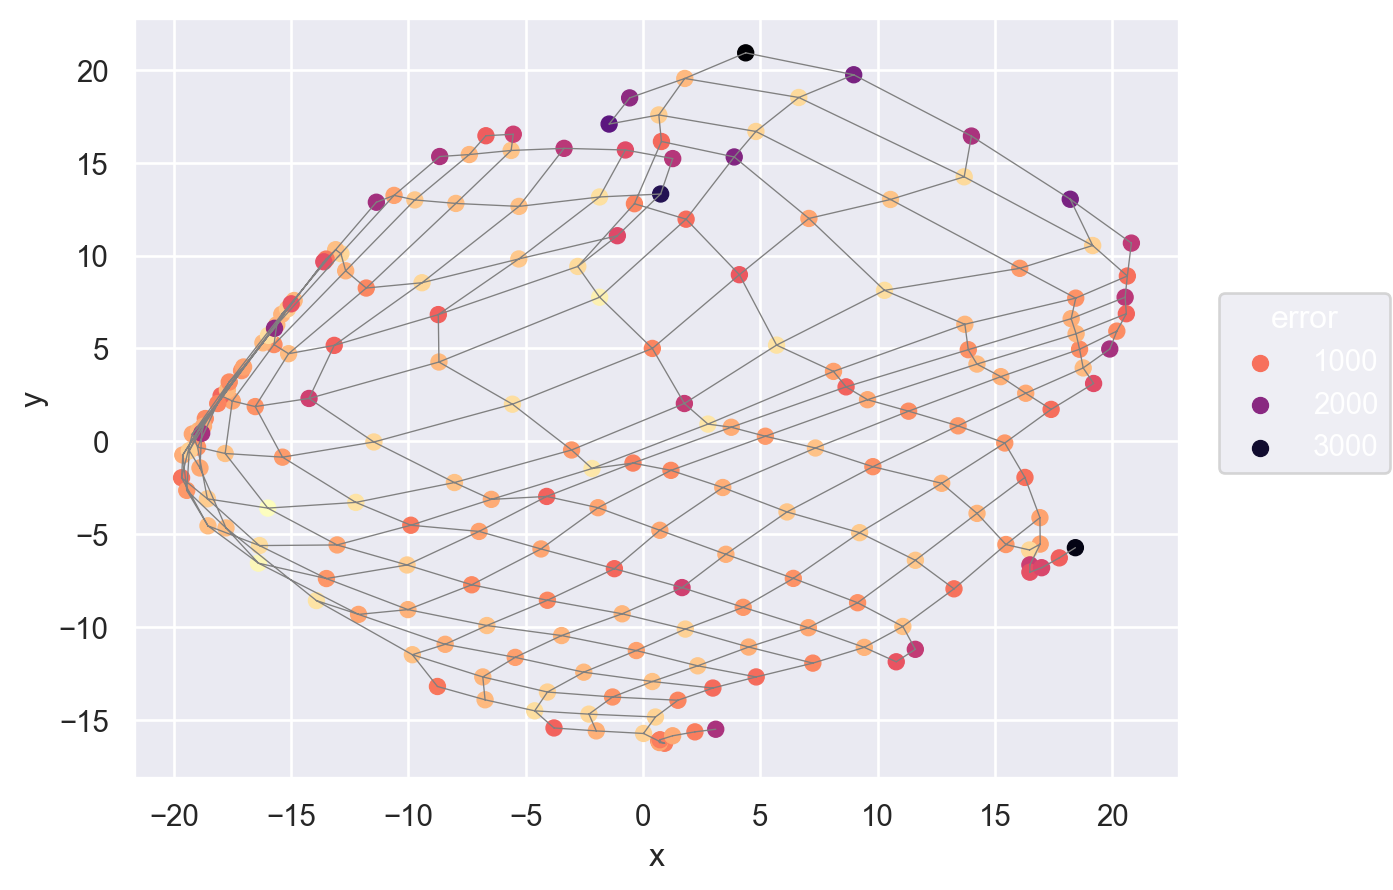

In [11]:
som_db_l.plot(color="error", layout="pca", X=X_large)

In [12]:
som_db_l

,spreading_factor,0.99
,sigma_end,1.5
,neighborhood_function,'cutgauss'
,verbose,True
,random_state,42
,convergence_threshold,1.0
,max_neurons,200
,n_iter,500
,sigma_start,None
,sigma_fine,None
,vertical_growth,False
